In [170]:
import pandas as pd
import numpy as np

**Basic DataFrame**
1. Consider the following Python dictionary data and Python list labels:

2.data = {'birds': ['Cranes', 'Cranes', 'plovers', 'spoonbills', 'spoonbills', 'Cranes', 'plovers', 'Cranes', 'spoonbills', 'spoonbills', 'Cranes'], 
        'age': [3.5, 4, 1.5, np.nan, 6, 3, 5.5, np.nan, 8, 4, 3.5], 'visits': [2, 4, 3, 4, 3, 4, 2, 2, 3, 2, 2], 
        'priority': ['yes', 'yes', 'no', np.nan, 'no', 'no', 'no', 'yes', 'no', 'no','yes']}
        
3. labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k']

**Q-1:**
1. Create a DataFrame birds from the above dictionary data which has the index labels.

2. Display basic information about the dataFrame.

3. Show Alternate rows of the dataframe.

In [136]:
data = {'birds': ['Cranes', 'Cranes', 'plovers', 'spoonbills', 'spoonbills', 'Cranes', 'plovers', 'Cranes', 'spoonbills', 'spoonbills', 'Cranes'], 
        'age': [3.5, 4, 1.5, np.nan, 6, 3, 5.5, np.nan, 8, 4, 3.5], 'visits': [2, 4, 3, 4, 3, 4, 2, 2, 3, 2, 2], 
        'priority': ['yes', 'yes', 'no', np.nan, 'no', 'no', 'no', 'yes', 'no', 'no','yes']}
labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k']

In [137]:
birds = pd.DataFrame(data ,index=labels)

In [138]:
birds.info()
birds.describe()

<class 'pandas.DataFrame'>
Index: 11 entries, a to k
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   birds     11 non-null     str    
 1   age       9 non-null      float64
 2   visits    11 non-null     int64  
 3   priority  10 non-null     str    
dtypes: float64(1), int64(1), str(2)
memory usage: 440.0+ bytes


,age,visits
count,9.000000,11.000000
mean,4.333333,2.818182
std,1.903943,0.873863
min,1.500000,2.000000
25%,3.500000,2.000000
50%,4.000000,3.000000
75%,5.500000,3.500000
max,8.000000,4.000000


In [139]:
# alternate rows
birds.iloc[::2]

,birds,age,visits,priority
a,Cranes,3.5,2,yes
c,plovers,1.5,3,no
e,spoonbills,6.0,3,no
g,plovers,5.5,2,no
i,spoonbills,8.0,3,no
k,Cranes,3.5,2,yes


**Q-2:**
1. Show only rows [1st, 3rd, 7th] from columns ['bird', 'age']

2. Select rows where the number of visits is less than 4.

In [140]:
birds.iloc[[0,2,3]].loc[ : , ['birds' , 'age']]
# OR
birds[['birds' , 'age']].iloc[[0,2,6]]

,birds,age
a,Cranes,3.5
c,plovers,1.5
g,plovers,5.5


In [141]:
birds[birds['visits'] < 4]

,birds,age,visits,priority
a,Cranes,3.5,2,yes
c,plovers,1.5,3,no
e,spoonbills,6.0,3,no
g,plovers,5.5,2,no
h,Cranes,NaN,2,yes
i,spoonbills,8.0,3,no
j,spoonbills,4.0,2,no
k,Cranes,3.5,2,yes


In [142]:
birds.birds

a        Cranes
b        Cranes
c       plovers
d    spoonbills
e    spoonbills
f        Cranes
g       plovers
h        Cranes
i    spoonbills
j    spoonbills
k        Cranes
Name: birds, dtype: str

**Q-3:**
1. Select all rows with nan values in age and visits column.

2. Fill nan with respective series mode value.


In [143]:
birds[(birds['age'].isnull()) | (birds['visits'].isnull())]
# OR
birds[(birds.age.isnull()) | (birds.visits.isna())]

,birds,age,visits,priority
d,spoonbills,NaN,4,NaN
h,Cranes,NaN,2,yes


In [144]:
birds['age'].mode()

0    3.5
1    4.0
Name: age, dtype: float64

In [145]:
birds['age'] = birds['age'].fillna(birds.age.mode()[0] )

In [146]:
# CLEANEST WAY 
birds.fillna({'age': birds.age.mode()[0] , 'priority' : birds.priority.mode()[0]}  , inplace=True)

,birds,age,visits,priority
a,Cranes,3.5,2,yes
b,Cranes,4.0,4,yes
c,plovers,1.5,3,no
d,spoonbills,3.5,4,no
e,spoonbills,6.0,3,no
f,Cranes,3.0,4,no
g,plovers,5.5,2,no
h,Cranes,3.5,2,yes
i,spoonbills,8.0,3,no
j,spoonbills,4.0,2,no


**Q-4**
1. Find the total number of visits of the bird Cranes

2. Find the number of each type of birds in dataframe.

3. Print no of duplicate rows

4. Drop Duplicates rows and make this changes permanent. Show dataframe after changes.

In [147]:
# 1
birds[birds.birds == 'Cranes'].visits.sum()

np.int64(14)

In [148]:
# 2
birds.birds.value_counts()

birds
Cranes        5
spoonbills    4
plovers       2
Name: count, dtype: int64

In [149]:
# 3
birds.duplicated().sum()

np.int64(2)

In [150]:
birds.drop_duplicates(inplace=True)

In [151]:
birds

,birds,age,visits,priority
a,Cranes,3.5,2,yes
b,Cranes,4.0,4,yes
c,plovers,1.5,3,no
d,spoonbills,3.5,4,no
e,spoonbills,6.0,3,no
f,Cranes,3.0,4,no
g,plovers,5.5,2,no
i,spoonbills,8.0,3,no
j,spoonbills,4.0,2,no


# IPL data

In [152]:
ipl = pd.read_csv('C:/Users/Lenovo/Desktop/Python/Pandas/datas/ipl-matches.csv')

In [153]:
ipl.head(3)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough


**Q-6 Write a code which can display the bar chart of top 5 teams who have played maximum number of matches in the IPL.**

**Hint:** Be careful the data is divided in 2 different cols(Team 1 and Team 2)

In [154]:
matches_played =(ipl['Team1'].value_counts() + ipl['Team2'].value_counts()).sort_values(ascending=False)

<Axes: xlabel='Team1'>

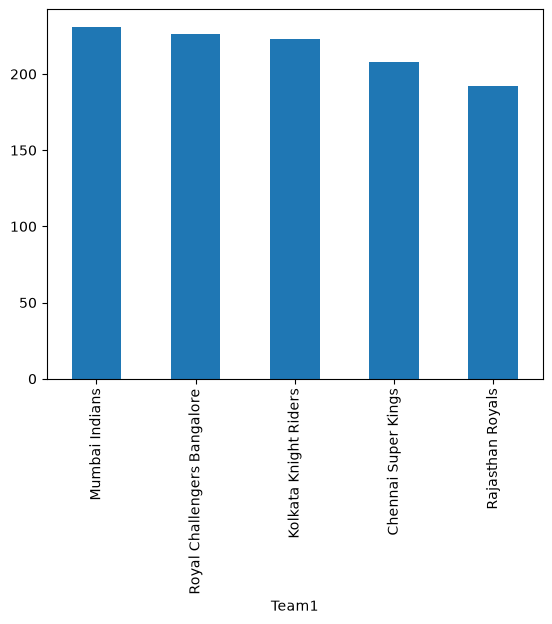

In [155]:
matches_played.head(5).plot(kind='bar')

**Q-7: Player who got Most no. of player of the match award playing against Mumbai Indians.**

Just for this question assume player of the match award is given to players from winning team.

 Although this is true in most of the cases.

In [156]:
ipl.sample()

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
336,1082628,Mumbai,2017-05-01,2017,38,Mumbai Indians,Royal Challengers Bangalore,Wankhede Stadium,Royal Challengers Bangalore,bat,N,Mumbai Indians,Wickets,5.0,NaN,RG Sharma,"['PA Patel', 'JC Buttler', 'N Rana', 'RG Sharm...","['V Kohli', 'Mandeep Singh', 'TM Head', 'AB de...",AK Chaudhary,CB Gaffaney


In [157]:
Mumbai_Indian_matches = ipl[(ipl.Team1 == 'Mumbai Indians') | (ipl.Team2 == 'Mumbai Indians')]

In [158]:
Mumbai_Indian_matches[(Mumbai_Indian_matches.WinningTeam != 'Mumbai Indians')].Player_of_Match.value_counts()

Player_of_Match
KL Rahul         4
SPD Smith        4
SK Raina         4
JC Buttler       3
A Mishra         3
                ..
PP Ojha          1
Sohail Tanvir    1
KD Karthik       1
AC Gilchrist     1
MV Boucher       1
Name: count, Length: 68, dtype: int64

**Q-8: Team1 vs Team2 Dashbord**

**Create a function which will take two string(name of two teams) as input.**

Show win Loss record between them and player getting most player of the match award in matches between these two teams.

team1_vs_team2('Kolkata Knight Riders','Chennai Super Kings')

In [159]:
def dash_board(T1 ,T2):
    matches = ipl[((ipl.Team1 == T1) | (ipl.Team1 == T2)) & ((ipl.Team2 == T1) | (ipl.Team2 == T2))]
    record = pd.concat([matches.WinningTeam.value_counts() , matches.Player_of_Match.value_counts().head(1)] , axis=0)
    return record


In [134]:
dash_board('Kolkata Knight Riders' , 'Chennai Super Kings')

Chennai Super Kings      17
Kolkata Knight Riders     9
RA Jadeja                 3
Name: count, dtype: int64

**Q-9: Find out the top 7 cities where the matches of Kolkata Knight Riders are played frequently and plot the result as bar chart.**

.plot(kind = "bar")

<Axes: xlabel='City'>

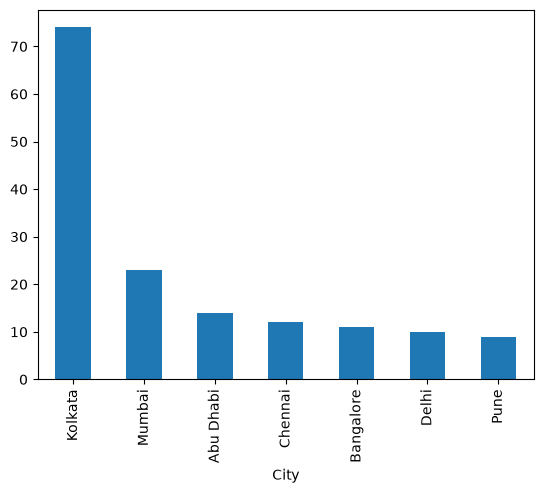

In [165]:
ipl[(ipl.Team1 == 'Kolkata Knight Riders') | (ipl.Team2 == 'Kolkata Knight Riders')].City.value_counts().head(7).plot(kind='bar')

**Q-10: Find out the average margin for the team Mumbai Indians for only the session 2011.**

In [169]:
ipl[(ipl.Season == '2011') & ((ipl.Team1 == 'Mumbai Indians') | (ipl.Team2 == 'Mumbai Indians'))].Margin.mean()

np.float64(19.25)